In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

df = pd.read_csv('./sample_data/MalBehavD-V1-dataset.csv')

api_cols = [str(i) for i in range(151)]
df['api_sequence'] = df[api_cols].apply(
    lambda row: ' '.join([x for x in row if pd.notna(x) and x != '']), axis=1
)

print(df.shape)
print(df['labels'].value_counts())
print(df['api_sequence'].iloc[0])

(2570, 178)
labels
0    1285
1    1285
Name: count, dtype: int64
LdrUnloadDll CoUninitialize NtQueryKey NtDuplicateObject GetShortPathNameW GetSystemInfo IsDebuggerPresent GetSystemWindowsDirectoryW NtClose GetFileVersionInfoSizeW NtOpenProcess GetFileAttributesW RegQueryValueExW NtMapViewOfSection RtlAddVectoredExceptionHandler GetFileSize RegOpenKeyExW SetErrorMode NtResumeThread NtAllocateVirtualMemory GetFileInformationByHandle LdrGetDllHandle NtFreeVirtualMemory NtQuerySystemInformation NtEnumerateValueKey RtlRemoveVectoredExceptionHandler NtReadFile NtOpenFile CoInitializeEx CreateThread NtUnmapViewOfSection RegQueryInfoKeyW GetSystemDirectoryW RegEnumKeyExW NtQueryDirectoryFile SetUnhandledExceptionFilter NtCreateFile NtCreateThreadEx GetSystemTimeAsFileTime GlobalMemoryStatusEx NtCreateMutant NtProtectVirtualMemory GetFileAttributesExW RegEnumValueW NtCreateSection NtOpenKey LdrGetProcedureAddress GetFileVersionInfoW NtOpenDirectoryObject GetFileType NtOpenKeyEx LdrLoadDll NtTe

=== Shape del dataset ===
Filas: 2570, Columnas: 178

=== Distribución de clases ===
labels
Benigno    1285
Malware    1285
Name: count, dtype: int64

=== Longitud de secuencias de API calls ===
Promedio: 13.8
Minimo:   0
Maximo:   151
Mediana:  16.0


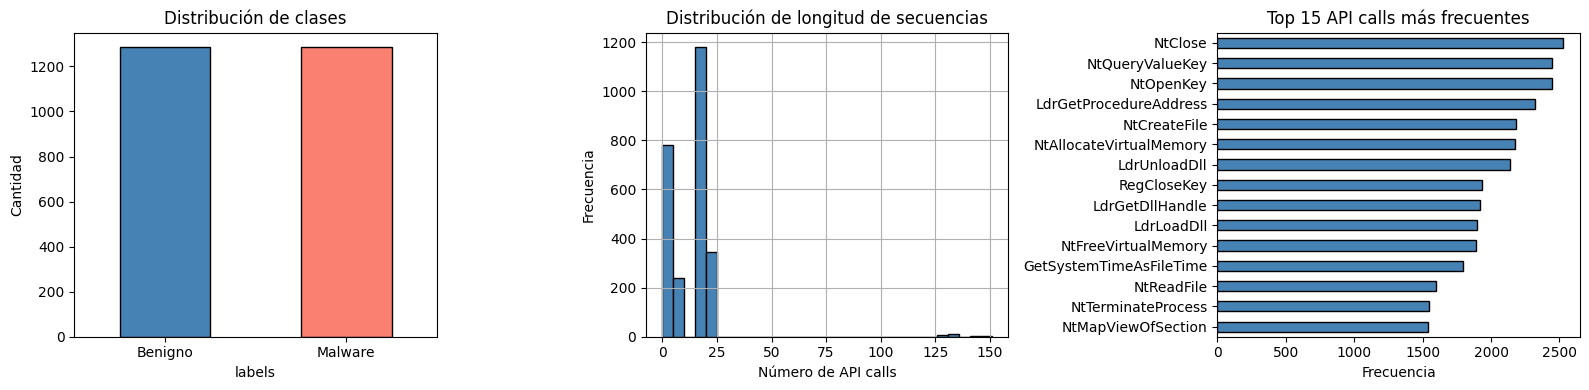

In [19]:
print("=== Shape del dataset ===")
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")

print("\n=== Distribución de clases ===")
print(df['labels'].value_counts().rename({0: 'Benigno', 1: 'Malware'}))

df['api_count'] = df[api_cols].apply(lambda row: row.notna().sum() & (row != '').sum(), axis=1)

print("\n=== Longitud de secuencias de API calls ===")
print(f"Promedio: {df['api_count'].mean():.1f}")
print(f"Minimo:   {df['api_count'].min()}")
print(f"Maximo:   {df['api_count'].max()}")
print(f"Mediana:  {df['api_count'].median()}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df['labels'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'], edgecolor='black')
axes[0].set_title('Distribución de clases')
axes[0].set_xticklabels(['Benigno', 'Malware'], rotation=0)
axes[0].set_ylabel('Cantidad')

df['api_count'].hist(bins=30, ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Distribución de longitud de secuencias')
axes[1].set_xlabel('Número de API calls')
axes[1].set_ylabel('Frecuencia')

all_apis = []
for seq in df['api_sequence']:
    all_apis.extend(seq.split())
api_freq = pd.Series(all_apis).value_counts().head(15)
api_freq.plot(kind='barh', ax=axes[2], color='steelblue', edgecolor='black')
axes[2].set_title('Top 15 API calls más frecuentes')
axes[2].set_xlabel('Frecuencia')
axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig('exploracion_datos.png', dpi=150)
plt.show()

In [20]:
print("=== Validación Cruzada (K-Fold, k=10) ===")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i:2d}: {score:.4f}")
print(f"\n  Media:          {cv_scores.mean():.4f}")
print(f"  Desviación std: {cv_scores.std():.4f}")
print(f"  Min:            {cv_scores.min():.4f}")
print(f"  Max:            {cv_scores.max():.4f}")

=== Validación Cruzada (K-Fold, k=10) ===
  Fold  1: 0.9833
  Fold  2: 0.9667
  Fold  3: 0.9722
  Fold  4: 0.9667
  Fold  5: 0.9444
  Fold  6: 0.9556
  Fold  7: 0.9444
  Fold  8: 0.9611
  Fold  9: 0.9722
  Fold 10: 0.9665

  Media:          0.9633
  Desviación std: 0.0117
  Min:            0.9444
  Max:            0.9833


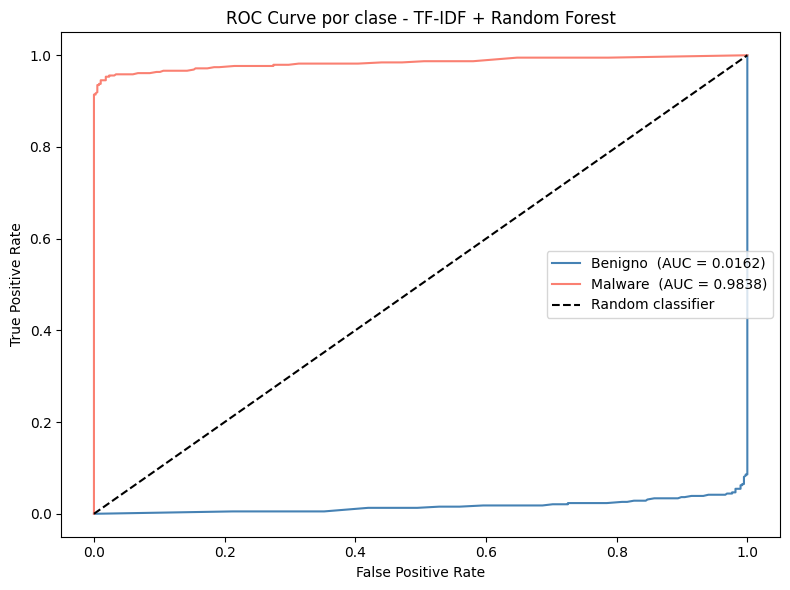

In [21]:
y_test_bin = label_binarize(y_test, classes=[0, 1])
y_prob_both = clf.predict_proba(X_test_tfidf)

fpr_b, tpr_b, _ = roc_curve(y_test_bin, y_prob_both[:, 0], pos_label=1)
auc_b = auc(fpr_b, tpr_b)

fpr_m, tpr_m, _ = roc_curve(y_test_bin, y_prob_both[:, 1], pos_label=1)
auc_m = auc(fpr_m, tpr_m)

plt.figure(figsize=(8, 6))
plt.plot(fpr_b, tpr_b, label=f'Benigno  (AUC = {auc_b:.4f})', color='steelblue')
plt.plot(fpr_m, tpr_m, label=f'Malware  (AUC = {auc_m:.4f})', color='salmon')
plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve por clase - TF-IDF + Random Forest')
plt.legend()
plt.tight_layout()
plt.savefig('roc_ambas_clases_modelo1.png', dpi=150)
plt.show()

In [22]:
X = df['api_sequence']
y = df['labels']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

tfidf = TfidfVectorizer()
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print('Train shape:', X_train_tfidf.shape)
print('Test shape:', X_test_tfidf.shape)

Train shape: (1799, 286)
Test shape: (771, 286)


In [23]:
clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_scores = cross_val_score(clf, X_train_tfidf, y_train, cv=kf, scoring='accuracy')

print(f'CV Accuracy (10-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

clf.fit(X_train_tfidf, y_train)
y_pred = clf.predict(X_test_tfidf)
y_prob = clf.predict_proba(X_test_tfidf)[:, 1]

print(f'Test Accuracy:  {accuracy_score(y_test, y_pred):.4f}')
print(f'Test Precision: {precision_score(y_test, y_pred):.4f}')
print(f'Test Recall:    {recall_score(y_test, y_pred):.4f}')

CV Accuracy (10-fold): 0.9633 ± 0.0117
Test Accuracy:  0.9663
Test Precision: 0.9891
Test Recall:    0.9429


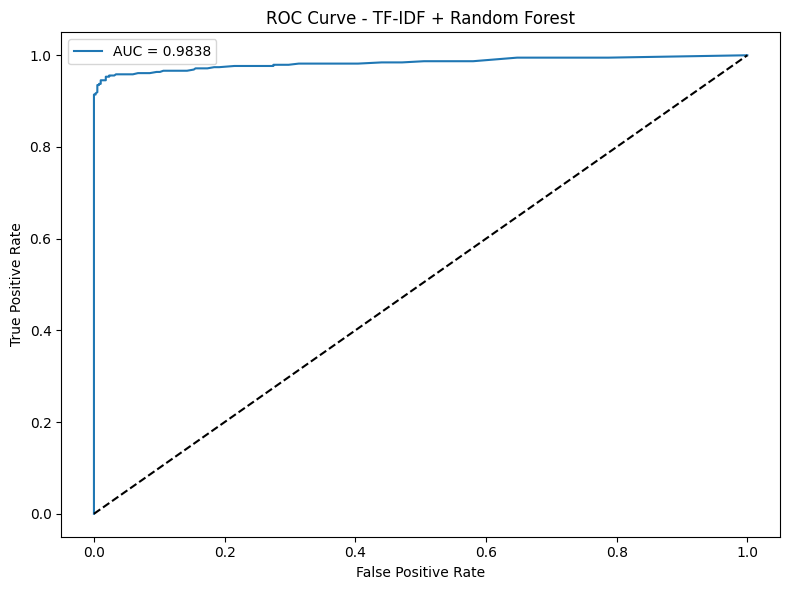

In [24]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - TF-IDF + Random Forest')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve_modelo1.png', dpi=150)
plt.show()

=== Classification Report ===
              precision    recall  f1-score   support

     Benigno       0.95      0.99      0.97       386
     Malware       0.99      0.94      0.97       385

    accuracy                           0.97       771
   macro avg       0.97      0.97      0.97       771
weighted avg       0.97      0.97      0.97       771



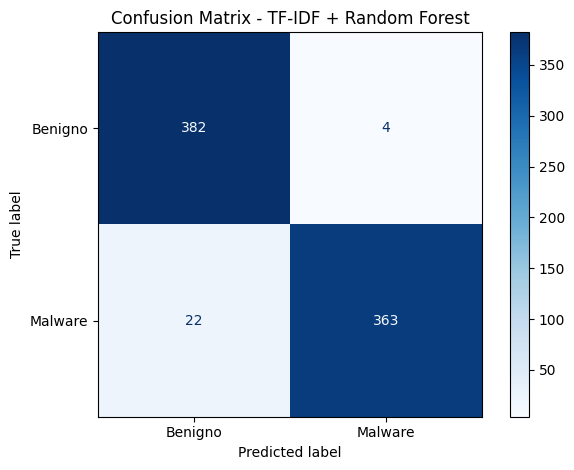

In [25]:
print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['Benigno', 'Malware']))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benigno', 'Malware'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - TF-IDF + Random Forest')
plt.tight_layout()
plt.savefig('confusion_matrix_modelo1.png', dpi=150)
plt.show()